In [2]:
# install requirements once
import pickle
import os
from mistralai import Mistral
import time
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
with open('merged_all_added_score.pkl', 'rb') as f:
    df = pickle.load(f)
df

,page_id,pagenumber,publication_date,place_of_distribution,language,plainpagefulltext,paper_title,score
0,UYPNVCGFNZRHE4VD4AV6LMBHODX7QDNA-FILE_0007_DDB...,7,1940-09-19 12:00:00,[Stuttgart],[ger],"fft, M — Schwäbischer Merkllr 3 Stuttgart — Do...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,1
1,5HNZ7CKJA23HRQVLH775UJINWQOLPLIT-FILE_0002_DDB...,2,1940-09-26 12:00:00,[Stuttgart],[ger],Nr. 226 — Schwäbischer Merkm Stuttgart — Donne...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
2,GTY6WLKCOIUQUTROD5AIF7YCHNQ25ITJ-FILE_0006_DDB...,6,1940-09-09 12:00:00,[Stuttgart],[ger],"8 Handelszeitung des Schwäbischen Merkur, Stut...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
3,JDRB3HLYATIXKFNZ4SY2IFFE6BI5SW6I-FILE_0005_DDB...,5,1940-09-18 12:00:00,[Stuttgart],[ger],"7 Schwäbischer Merkur (Schwäbische Kronik), St...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
4,VKUSW5DUFUGFJCRQOJJWQU4EQP4RSZWV-FILE_0004_DDB...,4,1940-09-16 12:00:00,[Stuttgart],[ger],"Nr. 217 — Schwäbischer Merkur Frage, bi« Mater...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,1
...,...,...,...,...,...,...,...,...
104031,OOYZ4LFEAKZJG6YIZB7VSYCKQYNIOKO2-FILE_0010_DDB...,10,1934-01-10 12:00:00,[Stuttgart],[ger],Nr. 6 — Seite 10 die Entwicklung der Vmeätxe l...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,0
104032,4M6YGR5JQA33FK62Q2UJNHILZQQHDC5G-FILE_0002_DDB...,2,1934-01-30 12:00:00,[Stuttgart],[ger],"SLllMWr Werter Dtmstag 30, Sanvar 1934 — Nr. z...",Schwäbischer Merkur : mit Schwäbischer Kronik ...,2
104033,7ZFSURJJ5HU2VCOIJJII7NPLHUIVV5QW-FILE_0007_DDB...,7,1934-01-17 12:00:00,[Stuttgart],[ger],7 BiWöifdier Merkur und vom tt auch ein stille...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,1
104034,2MWQKNRRCYTBWSFYXYAXWGCIQMKDRRZG-FILE_0007_DDB...,7,1934-01-24 12:00:00,[Stuttgart],[ger],n 4 eWIfdjtr MerbU lebenribejahenLem Ginn« dur...,Schwäbischer Merkur : mit Schwäbischer Kronik ...,0


In [70]:
df_tmp =df[df['score']!=""]
df_tmp['paper_title'].unique()


len(df)

25234

In [69]:
df_tmp = df[df['score'].astype(str).str.len() <= 5]
df_tmp_bigger = df[df['score'].astype(str).str.len() > 5]
len(df_tmp_bigger)

67

In [66]:
df_tmp = df_tmp[df_tmp['score'].isin(['1', '0', '-1', '2', '1.5', '-2','-1.6'])]
df_tmp['score'] = df_tmp['score'].astype(float)
#df_tmp = df_tmp[df_tmp['score']==0]

print(len(df_tmp[df_tmp['paper_title']=='Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung']))
print(len(df_tmp[df_tmp['paper_title']=='Hamburger Tageblatt : Zeitung der Nationalsozialistischen Deutschen Arbeiterpartei']))
print(len(df_tmp[df_tmp['paper_title']=='Vorwärts']))

#len(df_filtered[df_filtered['paper_title']=='Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung'])

11032
8031
6101


C:\Users\finke\AppData\Local\Temp\ipykernel_5264\1635192763.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['score'] = df_tmp['score'].astype(float)
C:\Users\finke\AppData\Local\Temp\ipykernel_5264\1635192763.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')
C:\Users\finke\AppData\Local\Temp\ipykernel_5264\1635192763.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

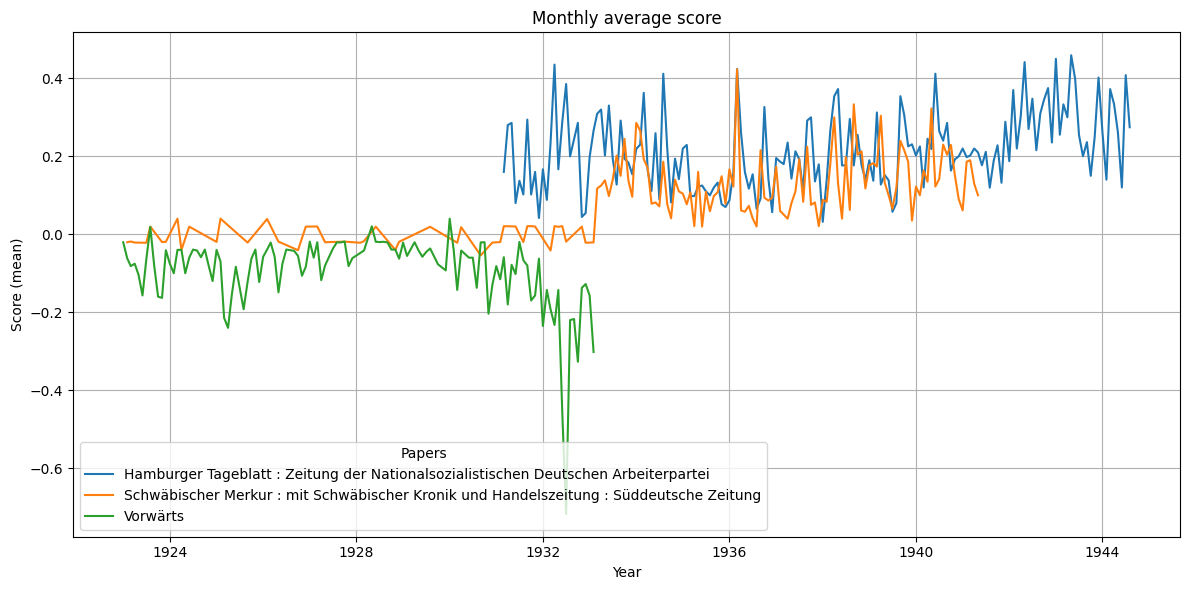

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter gültiger Scores
df_tmp = df[df['score'].isin(['1', '0', '-1', '2', '1.5', '-2','-1.6'])]
df_tmp['score'] = df_tmp['score'].astype(float)
df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')

# Gruppieren nach Titel, Woche und mittlerem Score
df_tmp['week'] = df_tmp['publication_date'].dt.to_period('M').dt.start_time

weekly_mean_scores = (
    df_tmp.groupby(['paper_title', 'week'])['score']
    .mean()
    .reset_index()
    .sort_values(by=['paper_title', 'week'])
)

# Nur Scores ≠ 0 plotten
score_grouped_tmp = weekly_mean_scores[weekly_mean_scores['score'] != 0]

# Plot
plt.figure(figsize=(12, 6))

for title in score_grouped_tmp['paper_title'].unique():
    df_paper = score_grouped_tmp[score_grouped_tmp['paper_title'] == title]
    plt.plot(df_paper['week'], df_paper['score'], label=title)

plt.title('Monthly average score')
plt.xlabel('Year')
plt.ylabel('Score (mean)')
plt.legend(title='Papers')
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\finke\AppData\Local\Temp\ipykernel_26884\1592220548.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['score'] = df_tmp['score'].astype(float)
C:\Users\finke\AppData\Local\Temp\ipykernel_26884\1592220548.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')


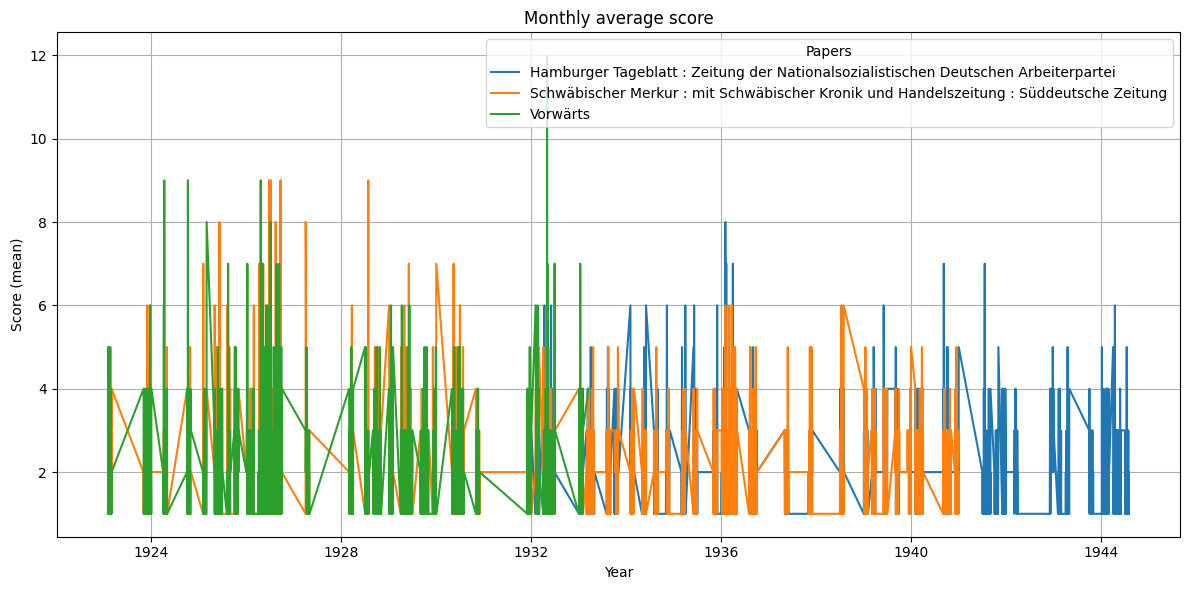

In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter gültiger Scores
df_tmp = df[df['score'].isin(['1', '0', '-1', '2', '1.5', '-2'])]
df_tmp['score'] = df_tmp['score'].astype(float)
df_tmp['publication_date'] = pd.to_datetime(df_tmp['publication_date'], errors='coerce')

# Gruppieren nach Titel, Woche und mittlerem Score
#df_tmp['week'] = df_tmp['publication_date'].dt.to_period('Y').dt.start_time

weekly_mean_scores = (
    df_tmp.groupby(['paper_title', 'publication_date'])['score']
    .count()
    .reset_index()
    .sort_values(by=['paper_title', 'publication_date'])
)

# Nur Scores ≠ 0 plotten
#weekly_mean_scores = weekly_mean_scores[weekly_mean_scores['paper_title'] != "Schwäbischer Merkur : mit Schwäbischer Kronik und Handelszeitung : Süddeutsche Zeitung"]
score_grouped_tmp = weekly_mean_scores[weekly_mean_scores['score'] != 0]

# Plot
plt.figure(figsize=(12, 6))

for title in score_grouped_tmp['paper_title'].unique():
    df_paper = score_grouped_tmp[score_grouped_tmp['paper_title'] == title]
    plt.plot(df_paper['publication_date'], df_paper['score'], label=title)

plt.title('Monthly average score')
plt.xlabel('Year')
plt.ylabel('Score (mean)')
plt.legend(title='Papers')
plt.grid(True)
plt.tight_layout()
plt.show()
